# ScamRadar+ — Data Understanding Notebook

**CRISP-DM Phase:** Data Understanding.

This notebook is the **presentation layer** for the Data Understanding phase. It does *not* re-implement acquisition. Every download, parse, and schema-normalisation step is executed by the production pipeline entry point `scamradar acquire`, whose implementation lives in `data_pipeline/src/scamradar/acquire.py` and whose source registry lives in `data_pipeline/src/scamradar/sources.py`.

**Defense workflow.** For every phase presented below, the notebook explains *what* happens and shows the *evidence* (statistics, cards, samples, plots). If the examiner asks *how* it is implemented, open the corresponding production file in VS Code.

**Handoff.** The artifact produced by this notebook — `data_pipeline/data/raw/canonical.parquet` (via the production acquire command) — is the input consumed by `notebooks/data_preparation.ipynb`.


## 0. Setup


In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.figsize'] = (10, 4.5)

# ─── Cache behaviour ──────────────────────────────────────────────────
FORCE_REBUILD = False   # flip to True to re-run acquisition from scratch

# ─── Repo root discovery ──────────────────────────────────────────────
# Walk up until we find the deployed model artifact + api/ — both only
# exist at the true repo root, not inside data_pipeline/ or notebooks/.
NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR
for _ in range(6):
    if (REPO_ROOT / 'models' / 'e7_p1_variants').exists() and (REPO_ROOT / 'api').exists():
        break
    REPO_ROOT = REPO_ROOT.parent
else:
    raise RuntimeError(f'Could not locate ScamRadar+ repo root from {NB_DIR}')

# ─── Production pipeline root ─────────────────────────────────────────
# Defaults to the in-repo data_pipeline/. Override with SCAMRADAR2_ROOT
# env var if the pipeline lives outside the repo on a given machine.
SCAMRADAR2_ROOT = Path(os.environ.get(
    'SCAMRADAR2_ROOT', str(REPO_ROOT / 'data_pipeline')
)).resolve()

# ─── Canonical artifacts produced by `scamradar acquire` ──────────────
CANONICAL_PARQUET    = SCAMRADAR2_ROOT / 'data' / 'raw' / 'canonical.parquet'
ACQUISITION_MANIFEST = SCAMRADAR2_ROOT / 'reports' / 'acquisition_manifest.json'

# ─── Make the production module importable ────────────────────────────
# Section 2 imports `scamradar.sources.SOURCES` (registry view) and the
# Section 8 appendix imports `scamradar.acquire.PARSERS` (per-source
# parser drill-down). Both come from the exact code `scamradar acquire`
# runs — no drift possible.
SCAMRADAR_SRC = SCAMRADAR2_ROOT / 'src'
if str(SCAMRADAR_SRC) not in sys.path:
    sys.path.insert(0, str(SCAMRADAR_SRC))

print(f'Repo root         : {REPO_ROOT}')
print(f'SCAMRADAR2_ROOT   : {SCAMRADAR2_ROOT}')
print(f'Canonical parquet : {CANONICAL_PARQUET}   (exists={CANONICAL_PARQUET.exists()})')
print(f'Manifest          : {ACQUISITION_MANIFEST}   (exists={ACQUISITION_MANIFEST.exists()})')
print(f'FORCE_REBUILD     : {FORCE_REBUILD}')


Repo root         : /Users/ameer/Downloads/ScamRadar
SCAMRADAR2_ROOT   : /Users/ameer/Downloads/ScamRadar/data_pipeline
Canonical parquet : /Users/ameer/Downloads/ScamRadar/data_pipeline/data/raw/canonical.parquet   (exists=True)
Manifest          : /Users/ameer/Downloads/ScamRadar/data_pipeline/reports/acquisition_manifest.json   (exists=True)
FORCE_REBUILD     : False


In [2]:
# ─── Cache-aware helper (mirrors the DP notebook pattern) ────────────

def cached_step(name: str, outputs, build_fn):
    """Run build_fn only if any expected output is missing (or if
    FORCE_REBUILD is set). Prints a clear status line either way."""
    outs = outputs if isinstance(outputs, list) else [outputs]
    missing = [o for o in outs if not o.exists()]

    print(f'── {name} ──')
    if not FORCE_REBUILD and not missing:
        for o in outs:
            print(f'  ✓ cached  {o}   ({o.stat().st_size / 1e6:.2f} MB)')
        return

    if FORCE_REBUILD:
        print('  ⟳ FORCE_REBUILD — running from scratch')
    else:
        print(f'  → building (missing: {[str(m) for m in missing]})')

    t0 = time.time()
    build_fn()
    dt = time.time() - t0

    still_missing = [o for o in outs if not o.exists()]
    if still_missing:
        raise RuntimeError(f'Build failed; still missing: {still_missing}')
    for o in outs:
        print(f'  ✓ built   {o}   ({o.stat().st_size / 1e6:.2f} MB)')
    print(f'  time: {dt:.1f}s')


# ─── Subprocess wrapper for the production CLI ───────────────────────
# `scamradar acquire` writes to data/raw/ and reports/ RELATIVE TO CWD,
# so we run it with CWD=SCAMRADAR2_ROOT.

PY = sys.executable

def run_scamradar(args: list[str]):
    cmd = [PY, '-m', 'scamradar', *args]
    # Make the scamradar package importable inside the subprocess.
    # (Notebook-level sys.path is not inherited by subprocesses.)
    env = {**os.environ, 'PYTHONPATH': str(SCAMRADAR2_ROOT / 'src')}
    print(f'  $ {" ".join(cmd)}   (cwd={SCAMRADAR2_ROOT})')
    subprocess.run(cmd, cwd=SCAMRADAR2_ROOT, check=True, env=env)


## 1. What Data Understanding means for this project

For a scam-detection classifier, Data Understanding is the phase in which we decide *which* signals the model will ever see — and honestly document them. In this project the phase has three commitments:

1. **Every source is registered explicitly** in `data_pipeline/src/scamradar/sources.py` with its URL, license, era (legacy / modern), platform (email / sms / chat / job_posting / mixed), default category, and `benchmark_eligible` flag. Registration is code, not documentation — the pipeline reads it directly.
2. **Every parse normalises to one canonical schema** so downstream phases never touch source-specific quirks: `sample_id, text, label, category, source, license, is_synthetic, era, platform, acquired_at`.
3. **No dataset is used because it was easy to find.** Every source is a peer-reviewed corpus, an institutional public release, or an explicit project-generated synthetic set — never a scraped mirror of unknown provenance.

The rest of the notebook demonstrates these commitments by orchestrating the production `scamradar acquire` command and inspecting the artifact it produces.


## 2. Source registry — dataset cards

The registry is loaded directly from the production module. If a source is added, removed, or re-licensed in `sources.py`, this section reflects it on the next run — no re-listing here.

*Implementation:* `data_pipeline/src/scamradar/sources.py::SOURCES`


In [3]:
from scamradar.sources import SOURCES

label_desc = {1: 'scam', 0: 'legit', -1: 'mixed (per-row)'}

registry_df = pd.DataFrame([
    {
        'source': s.name,
        'era': s.era,
        'platform': s.platform,
        'category': s.category,
        'label_mode': label_desc.get(s.label, str(s.label)),
        'auto_download': s.auto,
        'benchmark_eligible': s.benchmark_eligible,
        'license': s.license.split('(')[0].strip(),
    }
    for s in SOURCES
])

print(f'Registered sources: {len(SOURCES)}\n')
registry_df


Registered sources: 15



,source,era,platform,category,label_mode,auto_download,benchmark_eligible,license
0,sms_spam_collection,legacy,sms,smishing,mixed (per-row),True,True,CC BY 4.0
1,zenodo_champa_nazario_legacy,legacy,email,email_phishing,scam,True,True,CC BY 4.0
2,zenodo_champa_nazario_modern,modern,email,email_phishing,scam,True,True,CC BY 4.0
3,zenodo_champa_nigerian_fraud_legacy,legacy,email,advance_fee_fraud,scam,True,True,CC BY 4.0
4,zenodo_champa_nigerian_fraud_modern,modern,email,advance_fee_fraud,scam,True,True,CC BY 4.0
5,zenodo_champa_ceas08,legacy,email,email_phishing,mixed (per-row),True,True,CC BY 4.0
6,zenodo_miltchev_phishing_2024,modern,email,email_phishing,mixed (per-row),True,True,CC BY 4.0
7,mendeley_sms_phishing_2022,modern,sms,smishing,mixed (per-row),True,True,CC BY 4.0
8,emscad_job_scams,legacy,job_posting,recruitment_scam,mixed (per-row),True,True,EMSCAD research use
9,clair_fraud_email,legacy,email,advance_fee_fraud,scam,False,True,Research use


In [4]:
# Per-source detailed card. Everything comes from the SOURCES registry.

def render_card(s):
    print('─' * 78)
    print(f'{s.name}')
    print('─' * 78)
    print(f'  label mode          : {label_desc.get(s.label, s.label)}')
    print(f'  default category    : {s.category}')
    print(f'  platform            : {s.platform}')
    print(f'  era                 : {s.era}')
    print(f'  auto downloadable   : {s.auto}')
    print(f'  benchmark eligible  : {s.benchmark_eligible}')
    print(f'  license             : {s.license}')
    print(f'  url                 : {s.url}')
    if s.notes:
        print(f'  notes               : {s.notes}')

for s in SOURCES:
    render_card(s)
print('─' * 78)


──────────────────────────────────────────────────────────────────────────────
sms_spam_collection
──────────────────────────────────────────────────────────────────────────────
  label mode          : mixed (per-row)
  default category    : smishing
  platform            : sms
  era                 : legacy
  auto downloadable   : True
  benchmark eligible  : True
  license             : CC BY 4.0 (Almeida & Gomez Hidalgo, UCI SMS Spam Collection)
  url                 : https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip
  notes               : UCI ML Repository direct download (dataset 228). Zip contains SMSSpamCollection (tab-separated <label>\t<text>). Legacy: weight-capped via era tag.
──────────────────────────────────────────────────────────────────────────────
zenodo_champa_nazario_legacy
──────────────────────────────────────────────────────────────────────────────
  label mode          : scam
  default category    : email_phishing
  platform            : em

## 3. Run the production acquisition pipeline

One orchestration cell. Downloads every `auto=True` source, parses each with its registered parser, normalises to the canonical schema, and writes `canonical.parquet` + `reports/acquisition_manifest.json`.

Cached: if `canonical.parquet` already exists, the cell is a no-op (set `FORCE_REBUILD = True` in Section 0 to force a rerun).

*Implementation:* `data_pipeline/src/scamradar/acquire.py::run()` — dispatches to `data_pipeline/src/scamradar/acquire.py::PARSERS[...]` per source.


In [5]:
def build_acquire():
    run_scamradar(['acquire'])


cached_step('scamradar acquire',
            [CANONICAL_PARQUET, ACQUISITION_MANIFEST],
            build_acquire)


── scamradar acquire ──
  ✓ cached  /Users/ameer/Downloads/ScamRadar/data_pipeline/data/raw/canonical.parquet   (127.80 MB)
  ✓ cached  /Users/ameer/Downloads/ScamRadar/data_pipeline/reports/acquisition_manifest.json   (0.00 MB)


In [6]:
# Present the per-source manifest that acquire.py just wrote.
manifest = json.loads(ACQUISITION_MANIFEST.read_text())
manifest_df = pd.DataFrame(manifest)

print(f'Sources acquired: {len(manifest_df)}   '
      f'total rows: {manifest_df.rows.sum():,}\n')
manifest_df


Sources acquired: 14   total rows: 280,730



,source,url,license,rows,era,benchmark_eligible
0,sms_spam_collection,https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip,"CC BY 4.0 (Almeida & Gomez Hidalgo, UCI SMS Spam Collection)",5574,legacy,True
1,zenodo_champa_nazario_legacy,https://zenodo.org/api/records/8339691/files/Nazario.csv/content,"CC BY 4.0 (Champa, Rabbi & Zibran 2024; underlying Nazario corpus)",1565,legacy,True
2,zenodo_champa_nazario_modern,https://zenodo.org/api/records/8339691/files/Nazario_5.csv/content,"CC BY 4.0 (Champa, Rabbi & Zibran 2024; Nazario 5 refresh)",3065,modern,True
3,zenodo_champa_nigerian_fraud_legacy,https://zenodo.org/api/records/8339691/files/Nigerian_Fraud.csv/content,"CC BY 4.0 (Champa, Rabbi & Zibran 2024; Nigerian fraud base)",3332,legacy,True
4,zenodo_champa_nigerian_fraud_modern,https://zenodo.org/api/records/8339691/files/Nigerian_5.csv/content,"CC BY 4.0 (Champa, Rabbi & Zibran 2024; Nigerian 5 refresh)",6331,modern,True
5,zenodo_champa_ceas08,https://zenodo.org/api/records/8339691/files/CEAS_08.csv/content,"CC BY 4.0 (Champa, Rabbi & Zibran 2024; underlying CEAS 2008 corpus)",39154,legacy,True
6,zenodo_miltchev_phishing_2024,https://zenodo.org/records/13474746/files/Phishing_validation_emails.csv?download=1,"CC BY 4.0 (Miltchev, Rangelov & Genchev 2024; Zenodo 13474746)",2000,modern,True
7,mendeley_sms_phishing_2022,https://data.mendeley.com/public-files/datasets/f45bkkt8pr/files/edb361de-918d-469f-9106-e84823830665/file_downloaded,CC BY 4.0 (Mishra & Soni 2022; Mendeley dataset f45bkkt8pr v1),5971,modern,True
8,emscad_job_scams,https://raw.githubusercontent.com/FelixLuciano/Fake-JobPosting-Prediction/main/src/dataset/fake_job_postings.csv,"EMSCAD research use (Vidros et al. 2017, University of the Aegean); GitHub mirror",17879,legacy,True
9,spamassassin_ham,https://spamassassin.apache.org/old/publiccorpus/,Apache 2.0 (SpamAssassin Public Corpus),2752,legacy,True


## 4. Per-source description

Load the canonical parquet and describe each source: row count, class balance, mean text length, category distribution, and two sample rows. No re-derivation — pure inspection of the artifact `scamradar acquire` just wrote.

*Implementation:* the artifact schema is defined by `data_pipeline/src/scamradar/acquire.py::CANON_COLS`.


In [7]:
raw = pd.read_parquet(CANONICAL_PARQUET)

print(f'canonical.parquet: {len(raw):,} rows, {raw.source.nunique()} distinct sources')
print(f'schema           : {list(raw.columns)}')
print(f'dtypes           :')
print(raw.dtypes.to_string())

raw.head(3)


canonical.parquet: 280,730 rows, 14 distinct sources
schema           : ['sample_id', 'text', 'label', 'category', 'source', 'license', 'is_synthetic', 'era', 'platform', 'acquired_at']
dtypes           :
sample_id       object
text            object
label            int64
category        object
source          object
license         object
is_synthetic      bool
era             object
platform        object
acquired_at     object


,sample_id,text,label,category,source,license,is_synthetic,era,platform,acquired_at
0,4b43290cbafcf9e5cd75d60c102463845d7379b9,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",0,ham_sms,sms_spam_collection,"CC BY 4.0 (Almeida & Gomez Hidalgo, UCI SMS Spam Collection)",False,legacy,sms,2026-08-09T02:15:11.872935+00:00
1,c5498590eaaf0febbd7b21df3c32f23527fb1947,Ok lar... Joking wif u oni...,0,ham_sms,sms_spam_collection,"CC BY 4.0 (Almeida & Gomez Hidalgo, UCI SMS Spam Collection)",False,legacy,sms,2026-08-09T02:15:11.872935+00:00
2,15bbcb8342000bbe930225edab65adfb095e62e8,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std t...,1,smishing,sms_spam_collection,"CC BY 4.0 (Almeida & Gomez Hidalgo, UCI SMS Spam Collection)",False,legacy,sms,2026-08-09T02:15:11.872935+00:00


In [8]:
# Aggregate statistics per source.
def _pct_scam(g):
    return round(100.0 * g.label.mean(), 1)

per_source = (
    raw.groupby('source')
       .apply(lambda g: pd.Series({
           'rows': len(g),
           'pct_scam': _pct_scam(g),
           'mean_text_len': int(g.text.str.len().mean()),
           'median_text_len': int(g.text.str.len().median()),
           'era': g.era.iloc[0],
           'platform': g.platform.iloc[0],
       }))
       .sort_values('rows', ascending=False)
)
per_source


/var/folders/3w/h4z97vjx2lb0b5xvffbl6nc80000gn/T/ipykernel_1927/2814138704.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,rows,pct_scam,mean_text_len,median_text_len,era,platform
source,,,,,,
multiwoz_v22,105164,0.0,82,76,modern,chat
dailydialog,52778,0.0,83,68,modern,chat
zenodo_champa_ceas08,39154,55.8,1608,598,legacy,email
enron_ham_sample,33665,50.9,1507,712,legacy,email
emscad_job_scams,17879,4.8,2668,2522,legacy,job_posting
zenodo_champa_nigerian_fraud_modern,6331,100.0,2753,2058,modern,email
mendeley_sms_phishing_2022,5971,18.9,83,66,modern,sms
sms_spam_collection,5574,13.4,80,62,legacy,sms
zenodo_champa_nigerian_fraud_legacy,3332,100.0,2662,2564,legacy,email


In [9]:
# Two representative sample rows per source (first scam + first legit if both exist).
def _samples(g):
    picks = []
    scam = g[g.label == 1].head(1)
    legit = g[g.label == 0].head(1)
    if len(scam):  picks.append(scam)
    if len(legit): picks.append(legit)
    if not picks:  picks.append(g.head(1))
    return pd.concat(picks)

# Plain iteration avoids the pandas 2.2+ groupby.apply column-dropping quirk
# where the grouping key can be excluded from the result frame.
samples = pd.concat(
    [_samples(g) for _, g in raw.groupby('source')],
    ignore_index=True,
)[['source', 'label', 'category', 'text']]
samples['text'] = samples.text.str.slice(0, 220).str.replace('\n', ' ⏎ ', regex=False) + '…'
samples


,source,label,category,text
0,dailydialog,0,ham_chat,"Say , Jim , how about going for a few beers after dinner ?…"
1,emscad_job_scams,1,recruitment_scam,IC&E Technician ⏎ Staffing &amp; Re...
2,emscad_job_scams,0,ham_job_posting,"Marketing Intern ⏎ We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, conn..."
3,enron_ham_sample,1,email_spam,dobmeos with hgh my energy level has gone up ! stukm ⏎ introducing ⏎ doctor - formulated ⏎ hgh ⏎ human growth hormon...
4,enron_ham_sample,0,ham_email,christmas tree farm pictures…
5,mendeley_sms_phishing_2022,1,smishing,Please Stay At Home. To encourage the notion of staying at home. All tax-paying citizens are entitled to �305.96 or ...
6,mendeley_sms_phishing_2022,0,ham_sms,Your opinion about me? 1. Over 2. Jada 3. Kusruthi 4. Lovable 5. Silent 6. Spl character 7. Not matured 8. Stylish 9...
7,multiwoz_v22,0,ham_chat,i need a place to dine in the center thats expensive…
8,sms_spam_collection,1,smishing,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std t...
9,sms_spam_collection,0,ham_sms,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...…"


## 5. Corpus-level description

Global shape of the acquired corpus — the numbers a professor is most likely to ask about.


In [10]:
print('Class balance — overall')
print(raw.label.value_counts().rename({0: 'legit', 1: 'scam'}).to_string())
print()
print('Class balance by platform')
print(pd.crosstab(raw.platform, raw.label.map({0: 'legit', 1: 'scam'})).to_string())
print()
print('Class balance by era')
print(pd.crosstab(raw.era, raw.label.map({0: 'legit', 1: 'scam'})).to_string())


Class balance — overall
label
legit    222236
scam      58494

Class balance by platform
label         legit   scam
platform                  
chat         157942    319
email         37609  55288
job_posting   17014    865
sms            9671   2022

Class balance by era
label    legit   scam
era                  
legacy   58450  45471
modern  163786  13023


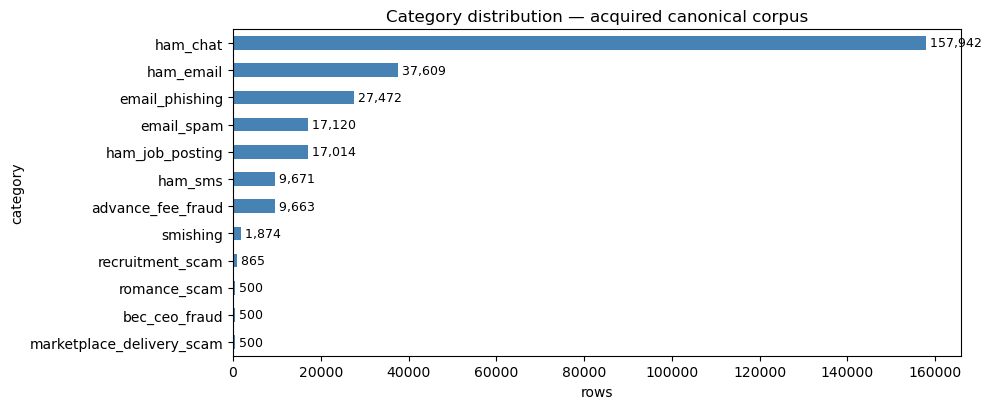

In [11]:
# Category distribution
cat_counts = raw.category.value_counts()
fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(cat_counts))))
cat_counts[::-1].plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('rows')
ax.set_title('Category distribution — acquired canonical corpus')
for i, v in enumerate(cat_counts[::-1].values):
    ax.text(v, i, f' {v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


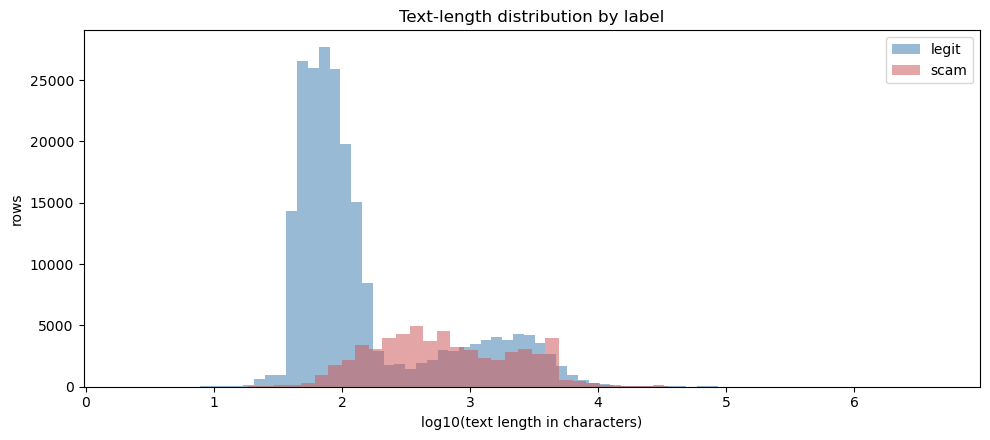

In [12]:
# Text-length distribution, log-scale, split by label.
lens = raw.text.str.len()
fig, ax = plt.subplots()
ax.hist(np.log10(lens[raw.label == 0].clip(lower=1)),
        bins=60, alpha=0.55, label='legit', color='steelblue')
ax.hist(np.log10(lens[raw.label == 1].clip(lower=1)),
        bins=60, alpha=0.55, label='scam', color='indianred')
ax.set_xlabel('log10(text length in characters)')
ax.set_ylabel('rows')
ax.set_title('Text-length distribution by label')
ax.legend()
plt.tight_layout()
plt.show()


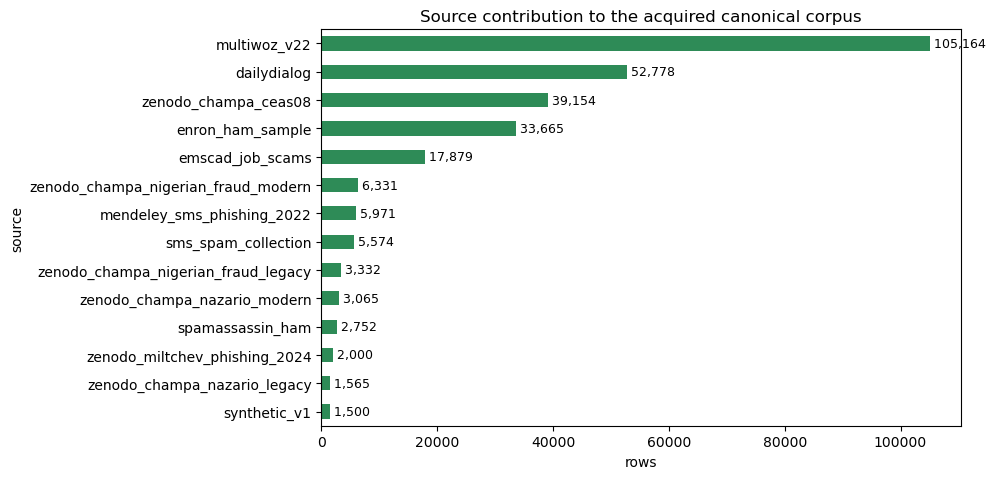

In [13]:
# Source mix (contribution to the corpus).
src_counts = raw.source.value_counts()
fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(src_counts))))
src_counts[::-1].plot.barh(ax=ax, color='seagreen')
ax.set_xlabel('rows')
ax.set_title('Source contribution to the acquired canonical corpus')
for i, v in enumerate(src_counts[::-1].values):
    ax.text(v, i, f' {v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


## 6. Data-quality checks (DU-level)

Light-touch integrity checks on the acquired canonical artifact. These verify the *schema contract* that Data Preparation expects. Heavy quality gates — exact-hash dedup, MinHash+LSH near-duplicate clustering, red-flag audit, human approval — belong to the DP phase (`scamradar clean` + `audit` + `approve-dataset`) and are demonstrated in the DP notebook.

*Implementation of the schema contract:* `data_pipeline/src/scamradar/acquire.py::CANON_COLS` and `_rows()`.


In [14]:
from scamradar.acquire import CANON_COLS

print('Expected schema (CANON_COLS):', CANON_COLS)
print()
print('Missing columns :', [c for c in CANON_COLS if c not in raw.columns] or 'none')
print('Extra columns   :', [c for c in raw.columns if c not in CANON_COLS] or 'none')
print()
print('Null counts per column')
print(raw.isna().sum().to_string())
print()
print(f'Rows            : {len(raw):,}')
print(f'Unique sample_id: {raw.sample_id.nunique():,}   '
      f'(collisions: {len(raw) - raw.sample_id.nunique():,})')
print()
print('Note: sample_id collisions across sources are expected and are handled by')
print('      the DP dedup stage (`scamradar clean`), not here.')


Expected schema (CANON_COLS): ['sample_id', 'text', 'label', 'category', 'source', 'license', 'is_synthetic', 'era', 'platform', 'acquired_at']

Missing columns : none
Extra columns   : none

Null counts per column
sample_id       0
text            0
label           0
category        0
source          0
license         0
is_synthetic    0
era             0
platform        0
acquired_at     0

Rows            : 280,730
Unique sample_id: 261,098   (collisions: 19,632)

Note: sample_id collisions across sources are expected and are handled by
      the DP dedup stage (`scamradar clean`), not here.


In [15]:
# License / benchmark-eligibility cross-check. `benchmark_eligible=False` sources
# must NOT appear in the frozen external benchmark that DP produces later.
acquired = set(raw.source.unique())
license_df = pd.DataFrame([
    {'source': s.name,
     'license': s.license,
     'benchmark_eligible': s.benchmark_eligible}
    for s in SOURCES if s.name in acquired
])
print(f'Sources present in canonical.parquet: {len(license_df)}')
print()
ineligible = license_df[~license_df.benchmark_eligible]
if len(ineligible):
    print('Benchmark-INELIGIBLE sources (must be reserved from external benchmark):')
    print(ineligible[['source', 'license']].to_string(index=False))
else:
    print('No benchmark-ineligible sources in the acquired corpus.')
print()
license_df


Sources present in canonical.parquet: 14

Benchmark-INELIGIBLE sources (must be reserved from external benchmark):
      source                                                                    license
 dailydialog CC BY-NC-SA 4.0 (Li et al. 2017, IJCNLP DailyDialog) — non-commercial only
synthetic_v1                                        Project-generated (no restrictions)



,source,license,benchmark_eligible
0,sms_spam_collection,"CC BY 4.0 (Almeida & Gomez Hidalgo, UCI SMS Spam Collection)",True
1,zenodo_champa_nazario_legacy,"CC BY 4.0 (Champa, Rabbi & Zibran 2024; underlying Nazario corpus)",True
2,zenodo_champa_nazario_modern,"CC BY 4.0 (Champa, Rabbi & Zibran 2024; Nazario 5 refresh)",True
3,zenodo_champa_nigerian_fraud_legacy,"CC BY 4.0 (Champa, Rabbi & Zibran 2024; Nigerian fraud base)",True
4,zenodo_champa_nigerian_fraud_modern,"CC BY 4.0 (Champa, Rabbi & Zibran 2024; Nigerian 5 refresh)",True
5,zenodo_champa_ceas08,"CC BY 4.0 (Champa, Rabbi & Zibran 2024; underlying CEAS 2008 corpus)",True
6,zenodo_miltchev_phishing_2024,"CC BY 4.0 (Miltchev, Rangelov & Genchev 2024; Zenodo 13474746)",True
7,mendeley_sms_phishing_2022,CC BY 4.0 (Mishra & Soni 2022; Mendeley dataset f45bkkt8pr v1),True
8,emscad_job_scams,"EMSCAD research use (Vidros et al. 2017, University of the Aegean); GitHub mirror",True
9,spamassassin_ham,Apache 2.0 (SpamAssassin Public Corpus),True


## 7. Initial ERD — planned relational schema

This is the target relational structure that Data Preparation will materialise. The `Source` and `Message` tables and their FK relationship are fully specified at DU time; the `MessageFeatures` table is a placeholder here — its 25 numerical columns are engineered in DP §5 and enumerated at that point.

The realised (final) ERD, populated with every feature column, is drawn in `notebooks/data_preparation.ipynb` §13.


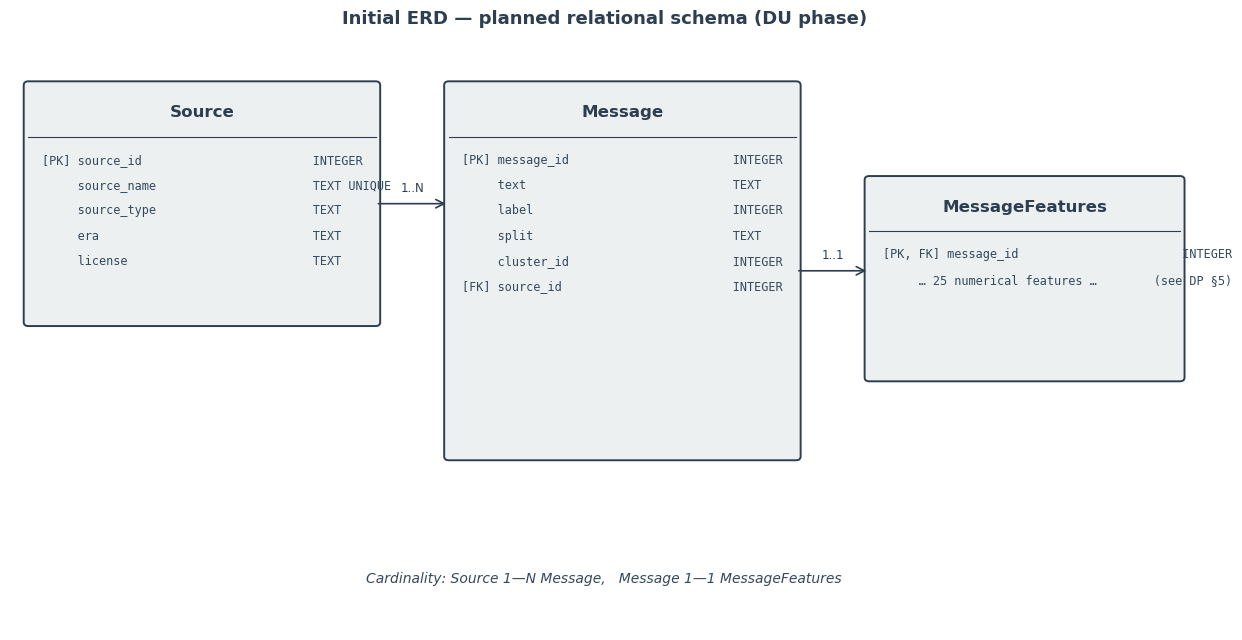

In [16]:
# Initial ERD — matplotlib-drawn so no external tools are required.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(13, 6.5))
ax.set_xlim(0, 13); ax.set_ylim(0, 7.5); ax.axis('off')


def entity(x, y, w, h, title, rows, pk_idx=(), fk_idx=()):
    ax.add_patch(FancyBboxPatch((x, y), w, h,
        boxstyle='round,pad=0.05', linewidth=1.4,
        edgecolor='#2c3e50', facecolor='#ecf0f1'))
    ax.text(x + w / 2, y + h - 0.35, title, ha='center', va='center',
            fontsize=12, fontweight='bold', color='#2c3e50')
    ax.plot([x, x + w], [y + h - 0.65, y + h - 0.65],
            color='#2c3e50', linewidth=0.8)
    for i, (col, typ) in enumerate(rows):
        marks = []
        if i in pk_idx: marks.append('PK')
        if i in fk_idx: marks.append('FK')
        prefix = f'[{", ".join(marks)}] ' if marks else '     '
        ax.text(x + 0.15, y + h - 0.95 - i * 0.32,
                f'{prefix}{col:32s} {typ}',
                ha='left', va='center',
                fontsize=8.5, family='monospace', color='#34495e')


# Source — fully specified at DU time.
entity(0.2, 3.9, 3.8, 3.0, 'Source', [
    ('source_id',   'INTEGER'),
    ('source_name', 'TEXT UNIQUE'),
    ('source_type', 'TEXT'),
    ('era',         'TEXT'),
    ('license',     'TEXT'),
], pk_idx=(0,))

# Message — text + label known at DU; split/cluster_id populated by DP.
entity(4.8, 2.2, 3.8, 4.7, 'Message', [
    ('message_id', 'INTEGER'),
    ('text',       'TEXT'),
    ('label',      'INTEGER'),
    ('split',      'TEXT'),
    ('cluster_id', 'INTEGER'),
    ('source_id',  'INTEGER'),
], pk_idx=(0,), fk_idx=(5,))

# MessageFeatures — placeholder; columns finalised in DP §5.
entity(9.4, 3.2, 3.4, 2.5, 'MessageFeatures', [
    ('message_id', 'INTEGER'),
    ('… 25 numerical features …', '(see DP §5)'),
], pk_idx=(0,), fk_idx=(0,))

# FK arrows.
ax.add_patch(FancyArrowPatch((4.0, 5.4), (4.8, 5.4),
    arrowstyle='->', mutation_scale=15, color='#2c3e50', linewidth=1.2))
ax.text(4.4, 5.55, '1..N', ha='center', fontsize=8.5, color='#2c3e50')

ax.add_patch(FancyArrowPatch((8.6, 4.55), (9.4, 4.55),
    arrowstyle='->', mutation_scale=15, color='#2c3e50', linewidth=1.2))
ax.text(9.0, 4.7, '1..1', ha='center', fontsize=8.5, color='#2c3e50')

ax.text(6.5, 0.6,
        'Cardinality: Source 1—N Message,   Message 1—1 MessageFeatures',
        ha='center', fontsize=10, style='italic', color='#34495e')
ax.set_title('Initial ERD — planned relational schema (DU phase)',
             fontsize=13, fontweight='bold', color='#2c3e50', pad=10)

plt.tight_layout()
plt.show()


## 8. Handoff to Data Preparation

`canonical.parquet` is the official DU output and the official DP input — one artifact, one path, no copy step. The Data Preparation notebook (`notebooks/data_preparation.ipynb`) reads it directly and orchestrates cleaning, splitting, feature engineering, the E8 synthetic chain, and the final relational database build.


In [17]:
size_mb = CANONICAL_PARQUET.stat().st_size / 1e6
print(f'DU artifact     : {CANONICAL_PARQUET}')
print(f'                  ({size_mb:.2f} MB, {len(raw):,} rows, '
      f'{raw.source.nunique()} sources)')
print()
print(f'DU manifest     : {ACQUISITION_MANIFEST}')
print()
print('Next: open notebooks/data_preparation.ipynb and run all cells.')
print('      That notebook reads canonical.parquet above and orchestrates')
print('      the full production pipeline through to the final SQLite DB.')


DU artifact     : /Users/ameer/Downloads/ScamRadar/data_pipeline/data/raw/canonical.parquet
                  (127.80 MB, 280,730 rows, 14 sources)

DU manifest     : /Users/ameer/Downloads/ScamRadar/data_pipeline/reports/acquisition_manifest.json

Next: open notebooks/data_preparation.ipynb and run all cells.
      That notebook reads canonical.parquet above and orchestrates
      the full production pipeline through to the final SQLite DB.


## 9. Appendix — inspect one source parser in isolation

For live demonstration during the defense: prove that the notebook is not scraping anything itself by calling one production parser directly.

*Implementation:* `data_pipeline/src/scamradar/acquire.py::PARSERS` (the same dict `run()` dispatches over).


In [18]:
from scamradar.acquire import PARSERS
from scamradar.sources import get as get_source

# Pick the smallest and most self-contained source — UCI SMS Spam Collection.
PROBE = 'sms_spam_collection'

src = get_source(PROBE)
print(f'Source          : {src.name}')
print(f'URL             : {src.url}')
print(f'License         : {src.license}')
print(f'Parser function : scamradar.acquire.PARSERS[{PROBE!r}]  '
      f'-> {PARSERS[PROBE].__name__}()')
print()

# Run the exact parser `scamradar acquire` dispatched to for this source.
# Requires CWD=SCAMRADAR2_ROOT because the parser writes downloads to data/raw/.
_cwd = Path.cwd()
os.chdir(SCAMRADAR2_ROOT)
try:
    probe_df = PARSERS[PROBE](src)
finally:
    os.chdir(_cwd)

print(f'Rows returned   : {len(probe_df):,}')
print(f'Class balance   : {probe_df.label.value_counts().to_dict()}')
print()
probe_df.head(3)


Source          : sms_spam_collection
URL             : https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip
License         : CC BY 4.0 (Almeida & Gomez Hidalgo, UCI SMS Spam Collection)
Parser function : scamradar.acquire.PARSERS['sms_spam_collection']  -> parse_sms_spam_collection()

Rows returned   : 5,574
Class balance   : {0: 4827, 1: 747}



,sample_id,text,label,category,source,license,is_synthetic,era,platform,acquired_at
0,4b43290cbafcf9e5cd75d60c102463845d7379b9,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",0,ham_sms,sms_spam_collection,"CC BY 4.0 (Almeida & Gomez Hidalgo, UCI SMS Spam Collection)",False,legacy,sms,2026-08-10T13:57:26.794142+00:00
1,c5498590eaaf0febbd7b21df3c32f23527fb1947,Ok lar... Joking wif u oni...,0,ham_sms,sms_spam_collection,"CC BY 4.0 (Almeida & Gomez Hidalgo, UCI SMS Spam Collection)",False,legacy,sms,2026-08-10T13:57:26.794142+00:00
2,15bbcb8342000bbe930225edab65adfb095e62e8,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std t...,1,smishing,sms_spam_collection,"CC BY 4.0 (Almeida & Gomez Hidalgo, UCI SMS Spam Collection)",False,legacy,sms,2026-08-10T13:57:26.794142+00:00


---

**End of Data Understanding notebook.**

The acquired canonical corpus lives at `data_pipeline/data/raw/canonical.parquet`. Continue to `notebooks/data_preparation.ipynb` to clean, split, feature-engineer, and materialise the final relational database.
